# Baseline ML Models — Notebook 4

Time to train the actual models. I'm using 3 models to compare against the LLM later:
- Logistic Regression — simple linear baseline
- Random Forest — ensemble of decision trees
- XGBoost — gradient boosting, usually the strongest on tabular data

I'm also running SHAP on XGBoost to understand which features matter most per patient. These SHAP values will be used later in notebook 5 to build the SHAP-guided LLM prompts — that's the unique part of this project.

In [ ]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base = '/content/drive/MyDrive/PTSD_Project'
processed = base + '/data/processed'
results = base + '/results'

print("done")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
done


## Loading the processed data

Loading both versions — scaled for Logistic Regression, unscaled for tree-based models.

In [ ]:
train_scaled = pd.read_csv(processed + '/train_scaled.csv')
test_scaled = pd.read_csv(processed + '/test_scaled.csv')

X_train_scaled = train_scaled.drop('label', axis=1)
y_train = train_scaled['label']

X_test_scaled = test_scaled.drop('label', axis=1)
y_test = test_scaled['label']

In [ ]:
## Loading unscaled data for tree models

train = pd.read_csv(processed + '/train.csv')
test = pd.read_csv(processed + '/test.csv')

X_train = train.drop('label', axis=1)
X_test = test.drop('label', axis=1)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # for AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_score) if y_score is not None else None

    return {
        'Model': name,
        'Accuracy': acc,
        'F1_macro': f1,
        'ROC_AUC': auc
    }

## Logistic Regression

Simple linear baseline. Using class_weight='balanced' to handle the imbalanced labels.

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight='balanced', max_iter=1000)

lr_results = evaluate_model(
    "Logistic Regression",
    logreg,
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

lr_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.9891411648568608,
 'F1_macro': 0.9687910487473568,
 'ROC_AUC': np.float64(1.0)}

LR gets AUC of 1.0 which looks suspicious at first. But it makes sense — the PHQ questions directly encode the label, so a linear model can learn a near-perfect decision boundary. This confirms that tabular models find this task easy. The real challenge is whether the LLM can match this from text.

In [ ]:
y_score_lr = logreg.predict_proba(X_test_scaled)[:, 1]

np.unique(y_score_lr)[:10]
pd.Series(y_score_lr).describe()

,0
count,1.013000e+03
mean,1.027440e-01
std,2.896468e-01
min,6.733679e-29
25%,4.749644e-12
50%,7.408627e-10
75%,3.296881e-06
max,1.000000e+00


## Random Forest

Ensemble of 100 decision trees. Added this to get a richer comparison table and a stronger non-linear baseline alongside XGBoost.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_results = evaluate_model(
    "Random Forest",
    rf,
    X_train, y_train,
    X_test, y_test
)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.9743336623889437,
 'F1_macro': 0.9117832261521972,
 'ROC_AUC': np.float64(0.9948838691403484)}

In [ ]:
pos = y_train.sum()
neg = len(y_train) - pos

scale_pos_weight = neg / pos
scale_pos_weight

np.float64(10.040871934604905)

## XGBoost

Gradient boosting model — usually the strongest performer on tabular data. This is expected to be our best baseline.

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_results = evaluate_model(
    "XGBoost",
    xgb,
    X_train, y_train,
    X_test, y_test
)

xgb_results

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:12:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'Model': 'XGBoost',
 'Accuracy': 0.9792694965449161,
 'F1_macro': 0.9404192748813175,
 'ROC_AUC': np.float64(0.9976278147571165)}

In [ ]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

results_df.to_csv(results + '/baseline_metrics.csv', index=False)

results_df

,Model,Accuracy,F1_macro,ROC_AUC
0,Logistic Regression,0.989141,0.968791,1.000000
1,Random Forest,0.974334,0.911783,0.994884
2,XGBoost,0.979269,0.940419,0.997628


In [ ]:
import joblib

joblib.dump(logreg, base + '/models/logreg.pkl')
joblib.dump(rf, base + '/models/rf.pkl')
joblib.dump(xgb, base + '/models/xgb.pkl')

['/content/drive/MyDrive/PTSD_Project/models/xgb.pkl']

In [ ]:
results_df.to_csv(results + '/baseline_metrics.csv', index=False)
print("saved to:", results + '/baseline_metrics.csv')

saved to: /content/drive/MyDrive/PTSD_Project/results/baseline_metrics.csv


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_conf_matrix(model, X_test, y_test, title):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_conf_matrices(models, X_tests, y_test, titles):
    fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

    if len(models) == 1:
        axes = [axes]

    for ax, model, X, title in zip(axes, models, X_tests, titles):
        y_pred = model.predict(X)
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

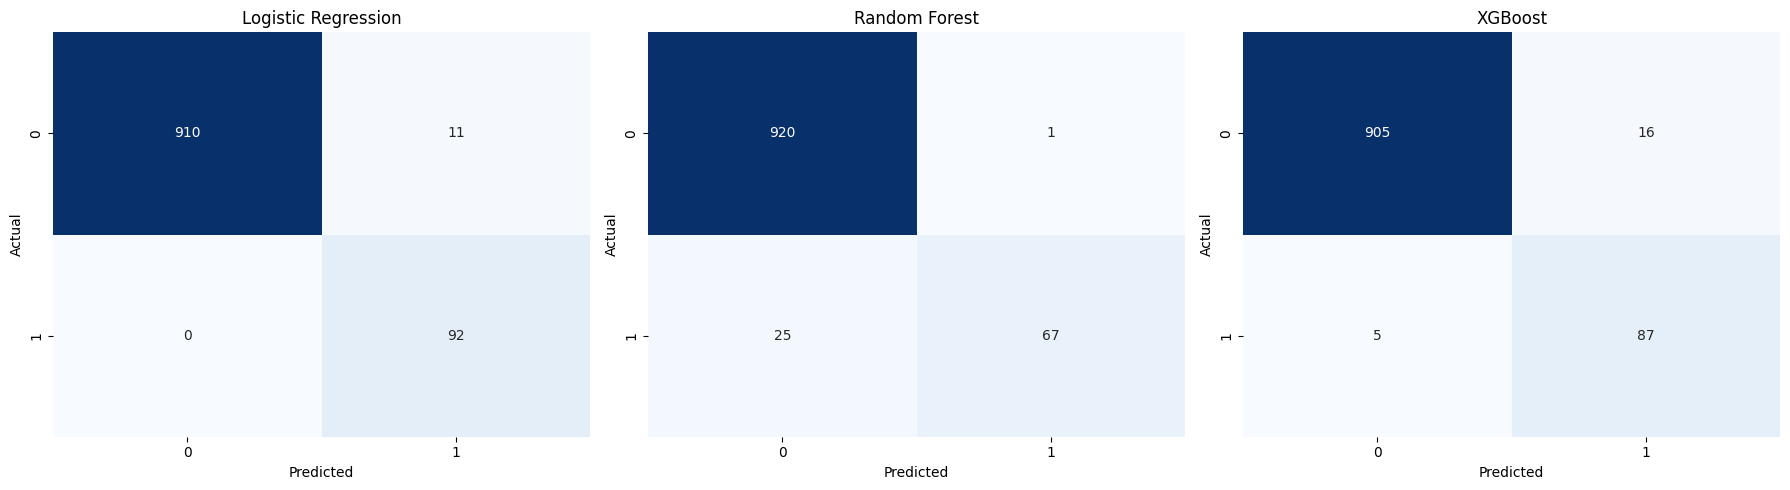

In [ ]:
plot_all_conf_matrices(
    models=[logreg, rf, xgb],
    X_tests=[X_test_scaled, X_test, X_test],
    y_test=y_test,
    titles=["Logistic Regression", "Random Forest", "XGBoost"]
)

In [ ]:
!pip install shap

## SHAP analysis on XGBoost

SHAP (SHapley Additive exPlanations) tells me which features drove each individual prediction. This does two things:
1. Gives me a global view of feature importance across all patients
2. Gives me per-patient top features which I'll use to build SHAP-guided prompts in notebook 5

This is the part that makes this project different from a standard ML comparison.

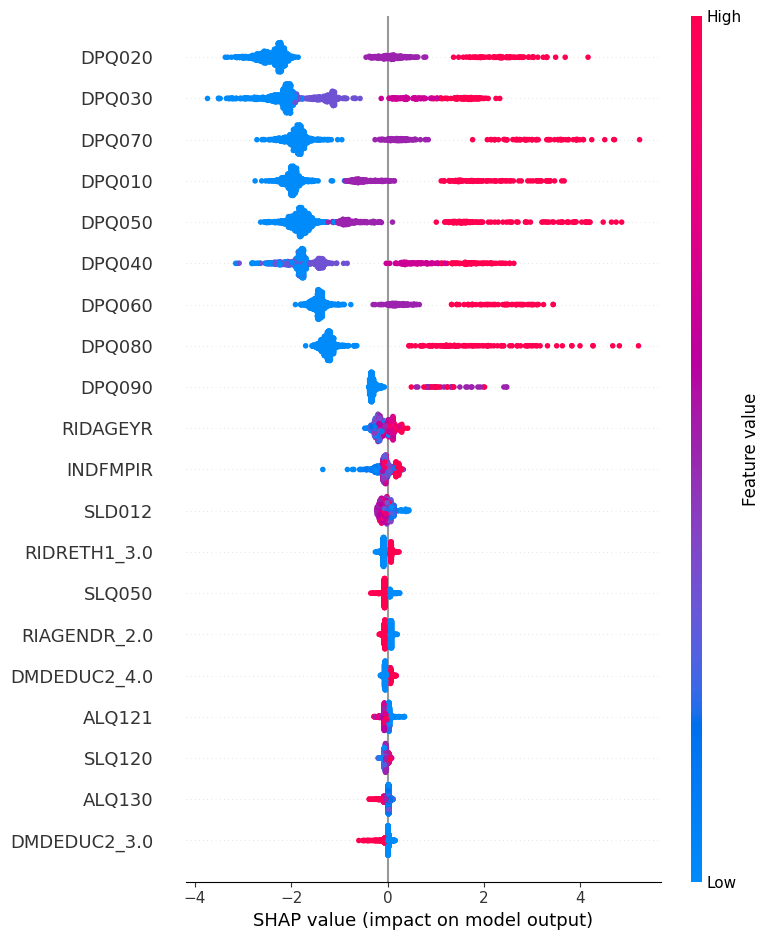

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
np.save(results + '/shap_values.npy', shap_values)

In [ ]:
import numpy as np
import pandas as pd

# absolute SHAP values
shap_abs = np.abs(shap_values)

# feature names
feature_names = X_test.columns

top_features_list = []

for i in range(shap_abs.shape[0]):
    top_idx = np.argsort(shap_abs[i])[-3:]  # top 3 features
    top_features = [feature_names[j] for j in top_idx]
    top_features_list.append(top_features)

# convert to dataframe
top_features_df = pd.DataFrame(top_features_list, columns=['Top1', 'Top2', 'Top3'])

top_features_df.head()

,Top1,Top2,Top3
0,DPQ010,DPQ030,DPQ020
1,DPQ030,DPQ010,DPQ020
2,DPQ050,DPQ020,DPQ030
3,DPQ030,DPQ050,DPQ060
4,DPQ050,DPQ040,DPQ020


In [ ]:
top_features_df.to_csv(results + '/top_features_per_patient.csv', index=False)

In [ ]:
top_features_with_values = []

for i in range(shap_abs.shape[0]):
    top_idx = np.argsort(shap_abs[i])[-3:]

    row_features = []
    for j in top_idx:
        feature = feature_names[j]
        value = X_test.iloc[i][feature]
        row_features.append(f"{feature}={value}")

    top_features_with_values.append(row_features)

top_features_df = pd.DataFrame(
    top_features_with_values,
    columns=['Top1', 'Top2', 'Top3']
)

top_features_df.head()

,Top1,Top2,Top3
0,DPQ010=0,DPQ030=0,DPQ020=0
1,DPQ030=0,DPQ010=0,DPQ020=0
2,DPQ050=0,DPQ020=0,DPQ030=0
3,DPQ030=1,DPQ050=0,DPQ060=2
4,DPQ050=0,DPQ040=0,DPQ020=0


In [ ]:
top_features_df.to_csv(results + '/top_features_with_values.csv', index=False)